In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from matplotlib.ticker import AutoMinorLocator
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for betweenness centrality
cut = 0.10
ms_threshold = filtered_nodes['betweenness_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['betweenness_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['betweenness_centrality'] <  ms_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.00203; there are 247 hubs and 2219 non hubs


## Supplement Fig 6A

* Create 2D histogram of stability metrices and melting point against Protein half-life for bottleneck proteins in AE-MS dataset

In [5]:
def calculate_hub_stability_correlations(df, hub_threshold_quantile=0.90):
    print("="*90)
    print("CORRELATION ANALYSIS: betweenness Centrality Hubs (MS/IPMS) vs Protein Stability")
    print("="*90)

    # Prepare full dataset
    base_cols = ['betweenness_centrality', 'Villen_halflife_min']
    stability_info = [
        ('Ghosh-Dill-dG', 'Ghosh-Dill ΔG'),
        ('cagiada-dG', 'Cagiada ΔG'),
        ('Rosetta_best_total_score', 'Rosetta Total Score'),
    ]

    # Special handling for meltome
    meltome_data = df[df['meltome-fit-R2'] >= 0.9].copy()
    if len(meltome_data) > 10:
        stability_info.append(('meltome-melting-point', 'Meltome Melting Point (°C)'))
        print(f"Meltome data (R² ≥ 0.9): {len(meltome_data)} proteins")
    else:
        print("Warning: Not enough high-quality meltome data (R² ≥ 0.9)")

    # Full data + hubs
    data = df[base_cols + [col for col, _ in stability_info]].dropna(subset=base_cols)
    hubs = data[data['betweenness_centrality'] >= data['betweenness_centrality'].quantile(hub_threshold_quantile)]

    print(f"\nTotal proteins with half-life: {len(data)}")
    print(f"Betweenness hubs (top 10%): {len(hubs)}")

    for stab_col, stab_name in stability_info:
        if stab_col not in data.columns:
            print(f"\nSkipping {stab_name} (column missing)")
            continue

        # Use filtered meltome only if it's that metric
        if stab_col == 'meltome-melting-point':
            current_data = meltome_data[[stab_col, 'Villen_halflife_min']].dropna()
            current_hubs = hubs[hubs.index.isin(meltome_data.index)]
        else:
            current_data = data[['Villen_halflife_min', stab_col]].dropna()
            current_hubs = hubs[[ 'Villen_halflife_min', stab_col]].dropna()

        print(f"\n→ {stab_name}")
        print(f"   n (all) = {len(current_data)}, n (hubs) = {len(current_hubs)}")

        # Spearman
        rho, p = spearmanr(current_data['Villen_halflife_min'], current_data[stab_col])
        print(f"   Spearman (all):  ρ = {rho:+.3f}, p = {p:.2g}")

        if len(current_hubs) > 5:
            rho_h, p_h = spearmanr(current_hubs['Villen_halflife_min'], current_hubs[stab_col])
            print(f"   Spearman (hubs): ρ = {rho_h:+.3f}, p = {p_h:.2g}")
        
        # Pearson on log(t½)
        log_t12 = np.log10(current_data['Villen_halflife_min'])
        r, p = pearsonr(log_t12, current_data[stab_col])
        print(f"   Pearson log(t½) (all):  r = {r:+.3f}, p = {p:.2g}")

        if len(current_hubs) > 5:
            log_t12_h = np.log10(current_hubs['Villen_halflife_min'])
            r_h, p_h = pearsonr(log_t12_h, current_hubs[stab_col])
            print(f"   Pearson log(t½) (hubs): r = {r_h:+.3f}, p = {p_h:.2g}")

# RUN IT
calculate_hub_stability_correlations(filtered_nodes, hub_threshold_quantile=0.90)

CORRELATION ANALYSIS: betweenness Centrality Hubs (MS/IPMS) vs Protein Stability
Meltome data (R² ≥ 0.9): 1328 proteins

Total proteins with half-life: 1825
Betweenness hubs (top 10%): 183

→ Ghosh-Dill ΔG
   n (all) = 1824, n (hubs) = 183
   Spearman (all):  ρ = +0.040, p = 0.087
   Spearman (hubs): ρ = +0.144, p = 0.052
   Pearson log(t½) (all):  r = +0.012, p = 0.62
   Pearson log(t½) (hubs): r = +0.126, p = 0.089

→ Cagiada ΔG
   n (all) = 1824, n (hubs) = 183
   Spearman (all):  ρ = -0.055, p = 0.019
   Spearman (hubs): ρ = +0.001, p = 0.99
   Pearson log(t½) (all):  r = -0.081, p = 0.00054
   Pearson log(t½) (hubs): r = -0.009, p = 0.91

→ Rosetta Total Score
   n (all) = 1824, n (hubs) = 183
   Spearman (all):  ρ = -0.010, p = 0.68
   Spearman (hubs): ρ = +0.081, p = 0.28
   Pearson log(t½) (all):  r = -0.027, p = 0.26
   Pearson log(t½) (hubs): r = -0.040, p = 0.59

→ Meltome Melting Point (°C)
   n (all) = 1176, n (hubs) = 148
   Spearman (all):  ρ = +0.256, p = 4.3e-19
   Spe

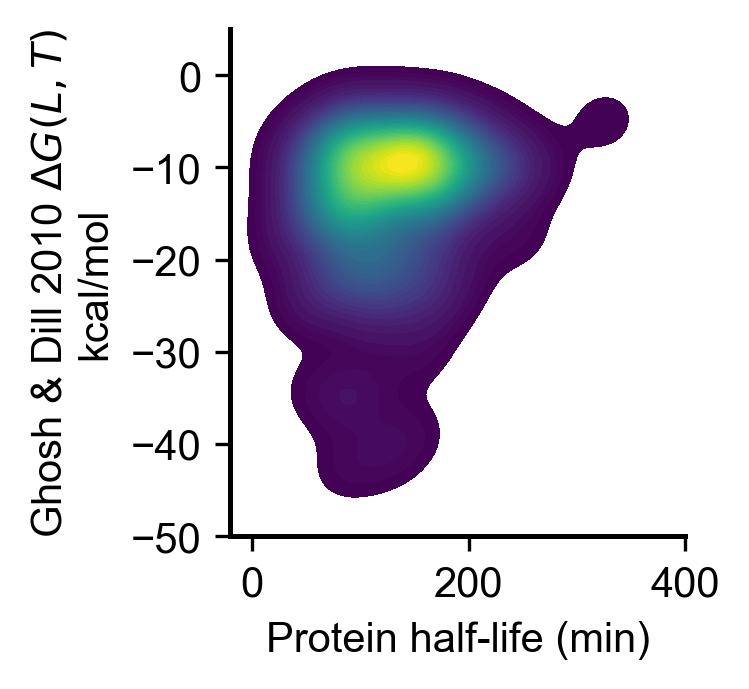

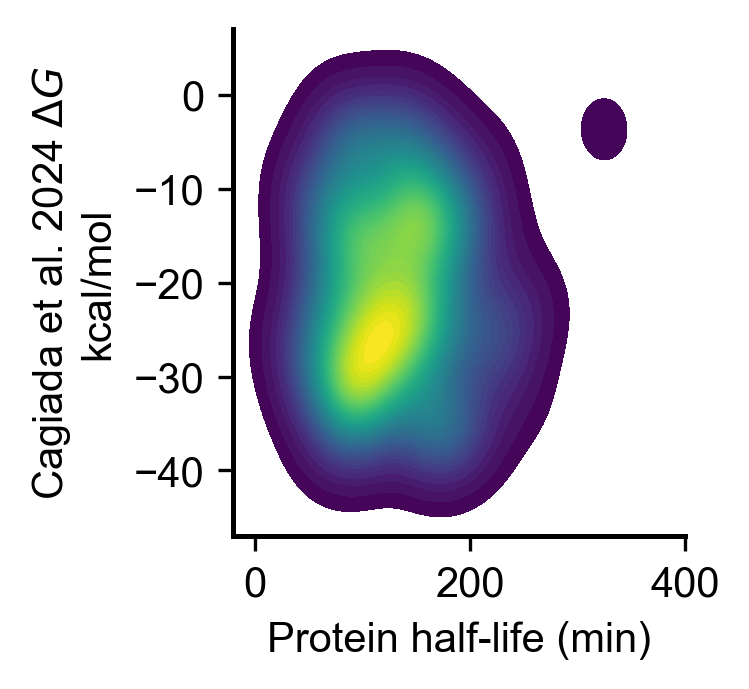

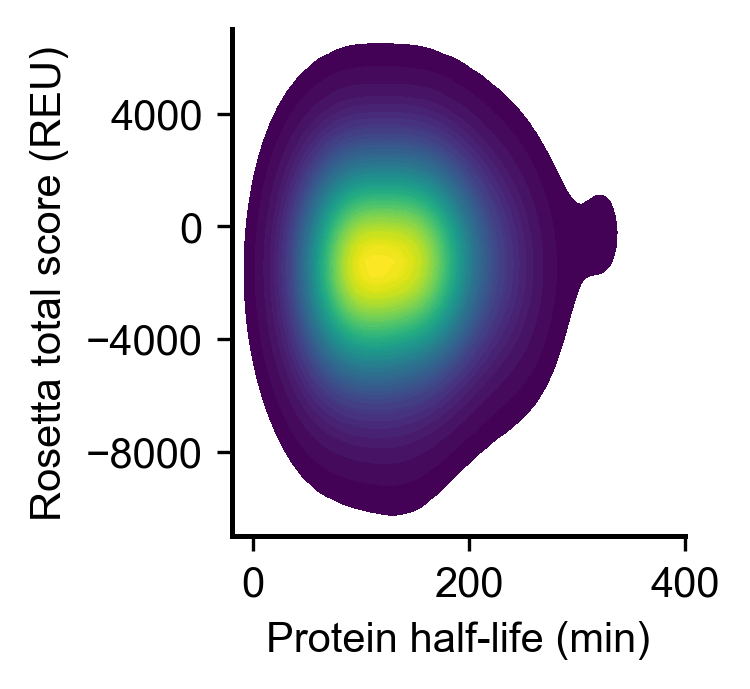

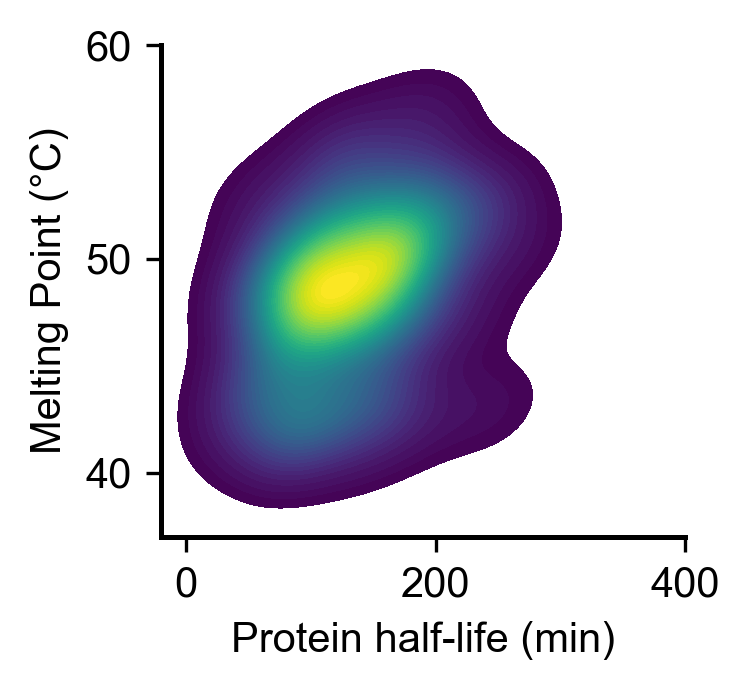

In [7]:
# Prepare data
plot_data = filtered_nodes.copy()

# Filter meltome strictly
meltome_hq = plot_data[plot_data['meltome-fit-R2'] >= 0.9]

def plot_hub_scatter(ax, data, x, y, ylabel, title):
    hubs = data[data['betweenness_centrality'] >= data['betweenness_centrality'].quantile(0.9)]

    sns.kdeplot(
        data=hubs,
        x=x,
        y=y,
        fill=True,
        cmap="viridis",
        levels=50,
        thresh=0.02,
        ax=ax
    )

    #ax.set_xscale('log')
    ax.set_xlim(-20, 400)
    #ax.minorticks_off()
    #ax.set_xticks([1, 10, 30, 100, 300, 400])
    #ax.get_xaxis().set_major_formatter(ticker.LogFormatterSciNotation())
    ax.set_xlabel('Protein half-life (min)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    
    sns.despine(ax=ax, trim=False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Ghosh–Dill ΔG 
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    plot_data,
    x='Villen_halflife_min',
    y='Ghosh-Dill-dG',
    ylabel=r"Ghosh & Dill 2010 $ΔG(L,T)$" + "\nkcal/mol",
    title=''
)
ax.set_ylim(-48, 5)
ax.set_yticks([0, -10, -20, -30, -40, -50])
plt.tight_layout()
fig.savefig("Supp6-1.svg", dpi=300, bbox_inches='tight')
plt.show()
    
# Cagiada ΔG
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    plot_data,
    x='Villen_halflife_min',
    y='cagiada-dG',
    ylabel=r"Cagiada et al. 2024 $ΔG$" + "\nkcal/mol",
    title=''
)
ax.set_ylim(-47, 7)
ax.set_yticks([0, -10, -20, -30, -40])
plt.tight_layout()
fig.savefig("Supp6-2.svg", dpi=300, bbox_inches='tight')
plt.show()

# Rosetta Total Score 
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    plot_data,
    x='Villen_halflife_min',
    y='Rosetta_best_total_score',
    ylabel='Rosetta total score (REU)',
    title=''
)
ax.set_ylim(-11000, 7000)
ax.set_yticks([4000, 0, -4000, -8000])
plt.tight_layout()
fig.savefig("Supp6-3.svg", dpi=300, bbox_inches='tight')
plt.show()


# Meltome Tm 
fig, ax = plt.subplots(figsize=(2.6, 2.4))
plot_hub_scatter(
    ax,
    meltome_hq,
    x='Villen_halflife_min',
    y='meltome-melting-point',
    ylabel='Melting Point (°C)',
    title=''
)
ax.set_ylim(37, 60)
ax.set_yticks([60, 50, 40])
plt.tight_layout()
fig.savefig("Supp6-4.svg", dpi=300, bbox_inches='tight')
plt.show()

## Supplement Fig 6B

* Create Box plots comparing protein turnover half-lives (t1/2, min) between static and dynamic bottleneck proteins (high betweenness centrality) in the AE-MS network

In [8]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=42):
    """
    Nonparametric bootstrap CI for the median
    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=np.float32)
    
    for b in trange(B, desc="Bootstrapping medians", leave=False):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)
    
    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

# Define MS betweenness hubs (top 10%)
ms_hubs = filtered_nodes[
    filtered_nodes['betweenness_centrality'] >= filtered_nodes['betweenness_centrality'].quantile(0.9)
].copy()

# Ensure boolean
ms_hubs['in_complex'] = ms_hubs['in_complex'].astype(bool)

# Split into Static (in complex) vs Dynamic (not in complex)
static_vals = ms_hubs[ms_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()
dynamic_vals = ms_hubs[~ms_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()

# NEW VARIABLE 
groups_step3 = [
    ("Static", static_vals, MS_COLOR_LIGHT),
    ("Dynamic", dynamic_vals, MS_COLOR_DARK),
]

print("=== Protein counts in Betweenness Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:8}: n = {len(vals)}")

# Bootstrapped medians
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []
for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:8}: median = {m:.1f} min, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Betweenness Hubs (MS) ===
Static  : n = 120
Dynamic : n = 87

=== Bootstrapped median half-life (95% CI) ===


Static  : median = 130.8 min, 95% CI = (117.0, 141.0)


Dynamic : median = 111.6 min, 95% CI = (99.0, 144.6)


In [9]:
# Mann-Whitney U test
u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='two-sided')
print("\n=== Mann–Whitney U test (Static vs Dynamic hubs) ===")
print(f"n(Static) = {len(static_vals)}, n(Dynamic) = {len(dynamic_vals)}")
print(f"median(Static) = {np.median(static_vals):.1f}, median(Dynamic) = {np.median(dynamic_vals):.1f}")
print(f"U = {u_stat:.1f}, p = {p_val:.2g}")
stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
print(f"Significance: {stars}")


=== Mann–Whitney U test (Static vs Dynamic hubs) ===
n(Static) = 120, n(Dynamic) = 87
median(Static) = 130.8, median(Dynamic) = 111.6
U = 5362.5, p = 0.74
Significance: N.S.


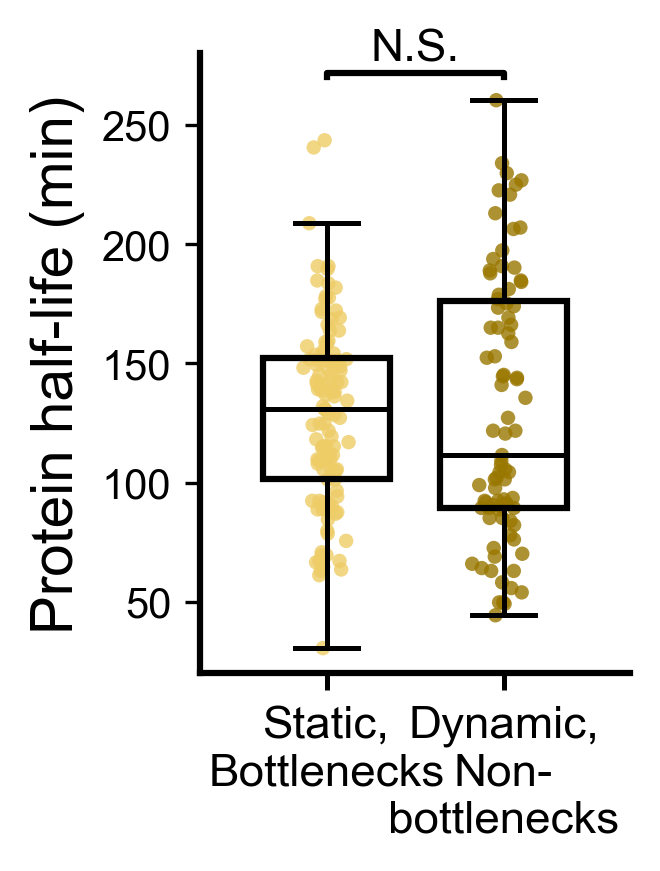

In [10]:
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 2    
    ax.plot([x1, x1, x2, x2],
            [y,  y_top, y_top, y],
            lw=1.5, 
            c="black",
            clip_on=False) 
    ax.text((x1 + x2)/2, 
            y_top + 1.05, 
            text,
            ha="center", 
            va="bottom", 
            fontsize=11,
           zorder=4)

# Prepare plot
fig, ax = plt.subplots(figsize=(2.3, 3))

positions = [1.0, 1.7]
group_data = [static_vals, dynamic_vals]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# Scatter (jittered)
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(x_jitter, vals, s=12, color=color,
               alpha=0.8, edgecolor="none", zorder=2)

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_data,
    tick_labels=["Static,\nBottlenecks", "Dynamic,\nNon-\nbottlenecks"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# === 3. X-axis labels ===
ax.set_xticks(positions)
ax.set_xticklabels(["Static,\nBottlenecks", "Dynamic,\nNon-\nbottlenecks"],
                       fontsize=11)
ax.tick_params(axis="x", length=4, width=1.2)

labs = ax.get_xticklabels()
labs[0].set_color("black")
labs[1].set_color("black")

# Styling
ax.set_ylim(20, 280)
ax.set_ylabel('Protein half-life (min)', fontsize=14)
bracket_y = 260
bracket_h = 2

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)


# Significance bracket
add_bracket_with_text(ax, positions[0], positions[1], y=270, text=stars)

# Bottom group label: "AE-MS" style
trans = ax.get_xaxis_transform()
#ax.plot([1.0, 1.7], [-0.26, -0.26], transform=trans, clip_on=False, color=MS_COLOR, lw=2.5)
#ax.text(1.4, -0.28, "AE-MS", transform=trans, ha="center", va="top",
#        fontsize=11, fontweight="bold", color=MS_COLOR)

plt.tight_layout()
plt.savefig("Supp6-5.svg", dpi=400, bbox_inches='tight')
plt.show()

## Supplement Fig 6C

* Create Box plots comparing stability metrices and melting point between static and dynamic bottleneck proteins (high betweenness centrality) in the AE-MS network

In [11]:
# === Prepare MS Betweenness Hubs (top 10%) ===
ms_hubs = filtered_nodes[
    filtered_nodes['betweenness_centrality'] >= filtered_nodes['betweenness_centrality'].quantile(0.9)
].copy()
ms_hubs['in_complex'] = ms_hubs['in_complex'].astype(bool)

# === Define the 4 stability metrics ===
stability_list = [
    ("Ghosh-Dill-dG",            "Ghosh-Dill ΔG"),
    ("cagiada-dG",               "Cagiada ΔG"),
    ("Rosetta_best_total_score", "Rosetta Total Score"),
    ("meltome-melting-point",    "Melting Point Tm (°C)"),
]

# === Extract clean values: Static vs Dynamic hubs ===
groups_step4 = []
for col, name in stability_list:
    if col == 'meltome-melting-point':
        data = ms_hubs[ms_hubs['meltome-fit-R2'] >= 0.9]   # High-quality meltome only
    else:
        data = ms_hubs
    
    static_vals  = data[data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    dynamic_vals = data[~data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    
    groups_step4.append((name, static_vals, dynamic_vals))

print("=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Betweenness Hubs ===\n")
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data")
        continue
    m_s, lo_s, hi_s = bootstrap_ci_median(static_vals, random_state=42)
    m_d, lo_d, hi_d = bootstrap_ci_median(dynamic_vals, random_state=42)
    print(f"{name:30} | Static:  {m_s:6.2f} [{lo_s:.1f}, {hi_s:.1f}]  (n={len(static_vals)})")
    print(f"{'':30} | Dynamic: {m_d:6.2f} [{lo_d:.1f}, {hi_d:.1f}]  (n={len(dynamic_vals)})\n")

=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Betweenness Hubs ===



Ghosh-Dill ΔG                  | Static:  -11.73 [-12.6, -10.7]  (n=142)
                               | Dynamic: -10.58 [-12.2, -10.0]  (n=105)



Cagiada ΔG                     | Static:  -21.33 [-23.7, -20.0]  (n=142)
                               | Dynamic: -21.61 [-25.0, -17.7]  (n=105)



Rosetta Total Score            | Static:  -1250.36 [-1417.6, -1098.6]  (n=142)
                               | Dynamic: -1196.97 [-1396.1, -989.7]  (n=105)



Melting Point Tm (°C)          | Static:   48.34 [47.2, 49.0]  (n=97)
                               | Dynamic:  48.71 [47.3, 50.5]  (n=80)



In [12]:
print("\n=== MANN–WHITNEY U TESTS (Static vs Dynamic in Betweenness Hubs) ===\n")

results = []
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data for test")
        results.append((name, np.nan, 1.0))
        continue
    
    u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='two-sided')
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    
    print(f"{name:30} | U = {u_stat:6.0f}, p = {p_val:.2g} {stars}")
    print(f"{'':32} Static median = {np.median(static_vals):.2f}, Dynamic = {np.median(dynamic_vals):.2f}\n")
    
    results.append((name, u_stat, p_val))


=== MANN–WHITNEY U TESTS (Static vs Dynamic in Betweenness Hubs) ===

Ghosh-Dill ΔG                  | U =   6830, p = 0.26 N.S.
                                 Static median = -11.73, Dynamic = -10.58

Cagiada ΔG                     | U =   7677, p = 0.69 N.S.
                                 Static median = -21.33, Dynamic = -21.61

Rosetta Total Score            | U =   7320, p = 0.81 N.S.
                                 Static median = -1250.36, Dynamic = -1196.97

Melting Point Tm (°C)          | U =   3495, p = 0.26 N.S.
                                 Static median = 48.34, Dynamic = 48.71



/tmp/ipykernel_1556/341202723.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp6-6.1.svg


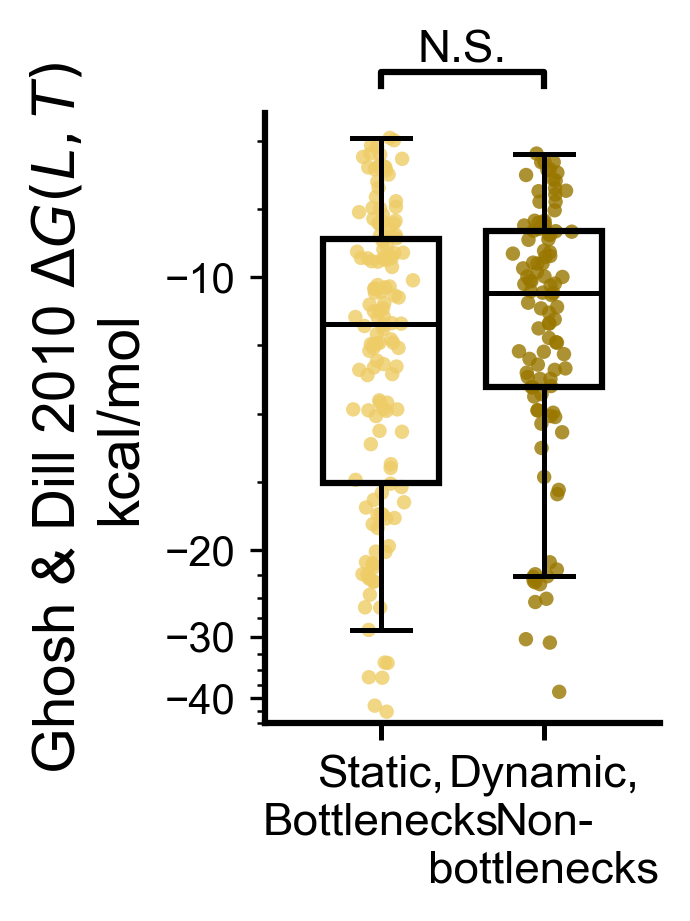

/tmp/ipykernel_1556/341202723.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp6-6.2.svg


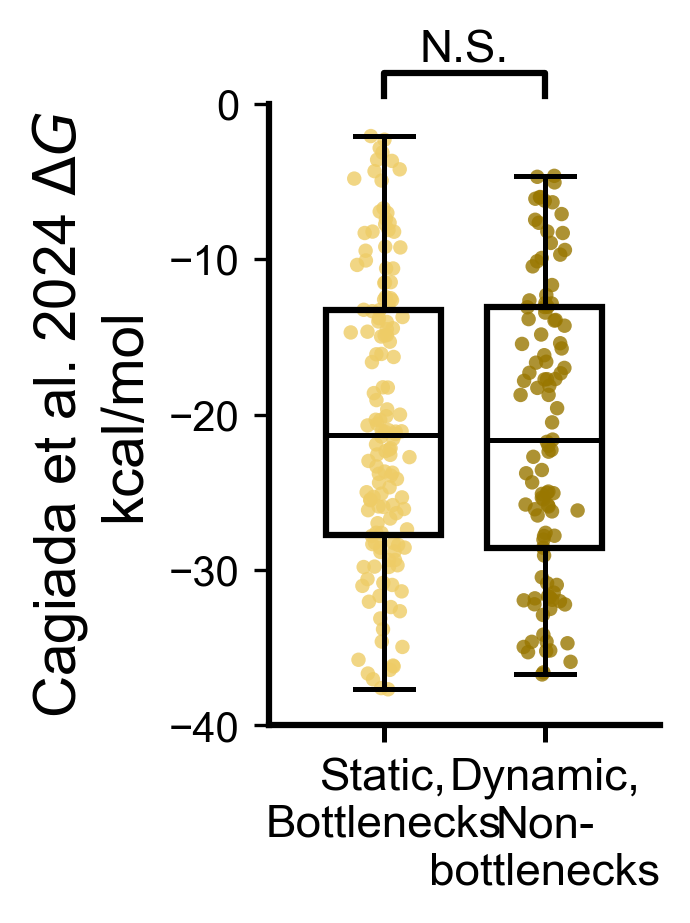

Saved: Supp6-6.3.svg


/tmp/ipykernel_1556/341202723.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


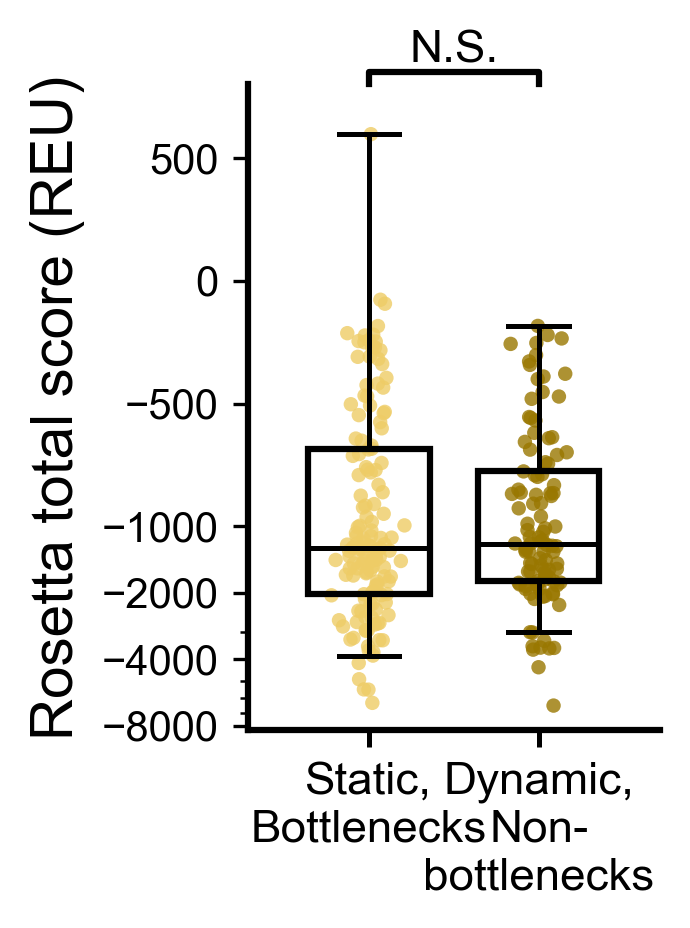

/tmp/ipykernel_1556/341202723.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp6-6.4.svg


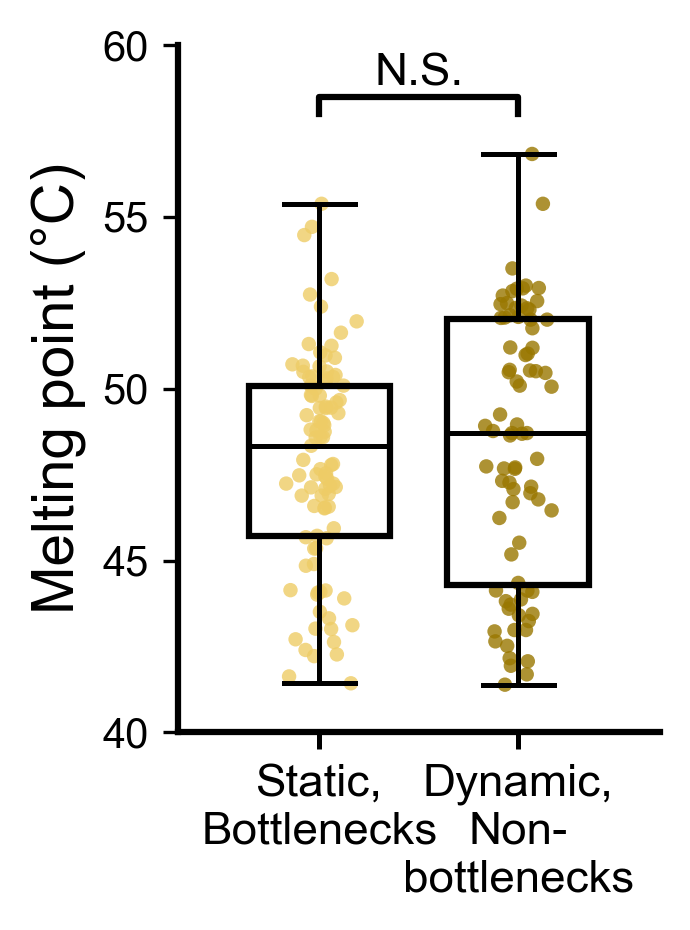

In [13]:
def draw_significance(ax, x1, x2, y, h, text):
    """
    Draws a straight bracket + text at EXACT y position and height h.
    - x1, x2 = x-coordinates of the two groups
    - y = vertical position of the bracket
    - h = height of the vertical bracket lines
    - text = significance stars
    """
    ax.plot([x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5, color="black", clip_on=False)
    
    ax.text((x1 + x2) / 2, y + h*1.1, text,
            ha="center", va="bottom",
            fontsize=11)


def base_box_scatter(ax, static_vals, dynamic_vals):
    positions = [1.0, 1.7]

    # === 1. Scatter ===
    for pos, vals, color in zip(
        positions,
        [static_vals, dynamic_vals],
        [MS_COLOR_LIGHT, MS_COLOR_DARK]
    ):
        x_jitter = pos + np.random.normal(0, 0.05, len(vals))
        ax.scatter(x_jitter, vals, s=12, alpha=0.8,
                   color=color, edgecolor="none", zorder=2)

    # === 2. Boxplot ===
    bp = ax.boxplot(
        [static_vals.values, dynamic_vals.values],
        positions=positions,
        labels=["Static,\nBottlenecks", "Dynamic,\nNon-\nbottlenecks"],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        zorder=3
    )

    for box in bp["boxes"]:
        box.set_facecolor("none")
        box.set_edgecolor("black")
        box.set_linewidth(1.5)

    for element in ["whiskers", "caps", "medians"]:
        plt.setp(bp[element], color="black", linewidth=1.2)

    # === 3. X-axis labels ===
    ax.set_xticks(positions)
    ax.set_xticklabels(["Static,\nBottlenecks", "Dynamic,\nNon-\nbottlenecks"],
                       fontsize=11)
    ax.tick_params(axis="x", length=4, width=1.2)

    labs = ax.get_xticklabels()
    labs[0].set_color("black")
    labs[1].set_color("black")

    #  === 4. Spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    return positions

figure_counter = 1
for stab_name, static_vals, dynamic_vals in groups_step4:

    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print("Skipping:", stab_name)
        continue

    fig, ax = plt.subplots(figsize=(2.4, 3.2))

    #  === 5. Base scatter+boxplot
    positions = base_box_scatter(ax, static_vals, dynamic_vals)
    ax.set_ylabel(stab_name, fontsize=11)
    ax.set_title("", fontsize=11)

    #  === 6. Metric-specific axis rules
    if "Rosetta" in stab_name:
        #ax.set_yscale("symlog", linthresh=10)
        ax.set_ylabel("Rosetta total score (REU)", fontsize=14)
        ax.set_yscale("symlog", linthresh=1000)
        ax.set_ylim(-8400, 800)
        ax.set_yticks([-8000, -4000, -2000, -1000, -500, 0, 500])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = 800   
        bracket_h = 50 

    elif "Meltome" in stab_name or "Tm" in stab_name:
        ax.set_ylabel(r"Melting point (°C)", fontsize=14)
        ax.set_ylim(40, 60)
        ax.set_yticks([40, 45, 50, 55, 60])
        bracket_y = 58    
        bracket_h = 0.5

    elif "Cagiada" in stab_name:
        ax.set_ylabel(r"Cagiada et al. 2024 $ΔG$" + "\nkcal/mol", fontsize=14)
        ax.set_ylim(-40, 0)
        ax.set_yticks([0, -10, -20, -30, -40])
        bracket_y = 0.5
        bracket_h = 1.5
        
    elif "Ghosh-Dill" in stab_name:
        ax.set_ylabel(r"Ghosh & Dill 2010 $ΔG(L,T)$" + "\nkcal/mol", fontsize=14)
        ax.set_yscale("symlog", linthresh=20)
        ax.set_ylim(-45, -4)
        ax.set_yticks([-10, -20, -30, -40])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = -3
        bracket_h = 0.5

    #  === 7. Significance stars
    p_val = [r[2] for r in results if r[0] == stab_name][0]
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    draw_significance(ax, positions[0], positions[1], bracket_y, bracket_h, stars)

    #  === 8. AE-MS label below plot
    #trans = ax.get_xaxis_transform()
    #ax.plot([1.0, 1.7], [-0.24, -0.24], transform=trans,
    #        clip_on=False, color=MS_COLOR, lw=1.5)
    #ax.text(1.4, -0.26, "AE-MS", transform=trans,
    #        ha="center", va="top", fontsize=10,
    #        fontweight="bold", color=MS_COLOR)

    # === 9. Save
    plt.tight_layout()
    out = f"Supp6-6.{figure_counter}.svg"
    plt.savefig(out, dpi=400, bbox_inches="tight")
    print("Saved:", out)

    figure_counter += 1
    plt.show()